In [2]:
import matplotlib
import numpy as np

from matplotlib import pyplot as plt
from model_tools import ModelAnalysis, RasterAnalysis, make_image

In [3]:
#Set plotting look and feel

host_color = matplotlib.colors.to_rgb('#558ADB')
path_color = matplotlib.colors.to_rgb('#FF4C32')
coevol_color = matplotlib.colors.to_rgb('#FFB91A')

s_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white", host_color])
i_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white", path_color])

plot_label_size = 12
axis_title_size = 12
axis_label_size = 8
tick_label_size = 6

matplotlib.rcParams['axes.titlesize'] = axis_title_size
matplotlib.rcParams['axes.labelsize'] = axis_label_size
matplotlib.rcParams['xtick.labelsize'] = tick_label_size
matplotlib.rcParams['ytick.labelsize'] = tick_label_size

matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{xfrac}'

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'Helvetica'
})

In [4]:
def label_x_axis(ax, n_x_ticks = 3):
    x_lim = ax.get_xlim()
    x_ticks = np.linspace(x_lim[0], x_lim[1], n_x_ticks)
    x_tick_labels = np.linspace(0, host_model.N_iter, n_x_ticks)

    ax.set_xticks(x_ticks, x_tick_labels.astype(int))

# Figure S1: Effects of Initial Conditions Raster #

In [52]:
host_path = 'data/default_init_50_coevol.p'
path_path = 'data/default_init_50_coevol.p'
coevol_path_50 = 'data/default_init_50_coevol.p'
coevol_path_60 = 'data/default_init_60_coevol.p'

coevol_raster_50 = RasterAnalysis(coevol_path_50, arg_x='m', arg_y='z')
coevol_raster_60 = RasterAnalysis(coevol_path_60, arg_x='m', arg_y='z')

/tmp/ipykernel_475414/989841674.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])


Text(-0.1, 1.1, 'F')

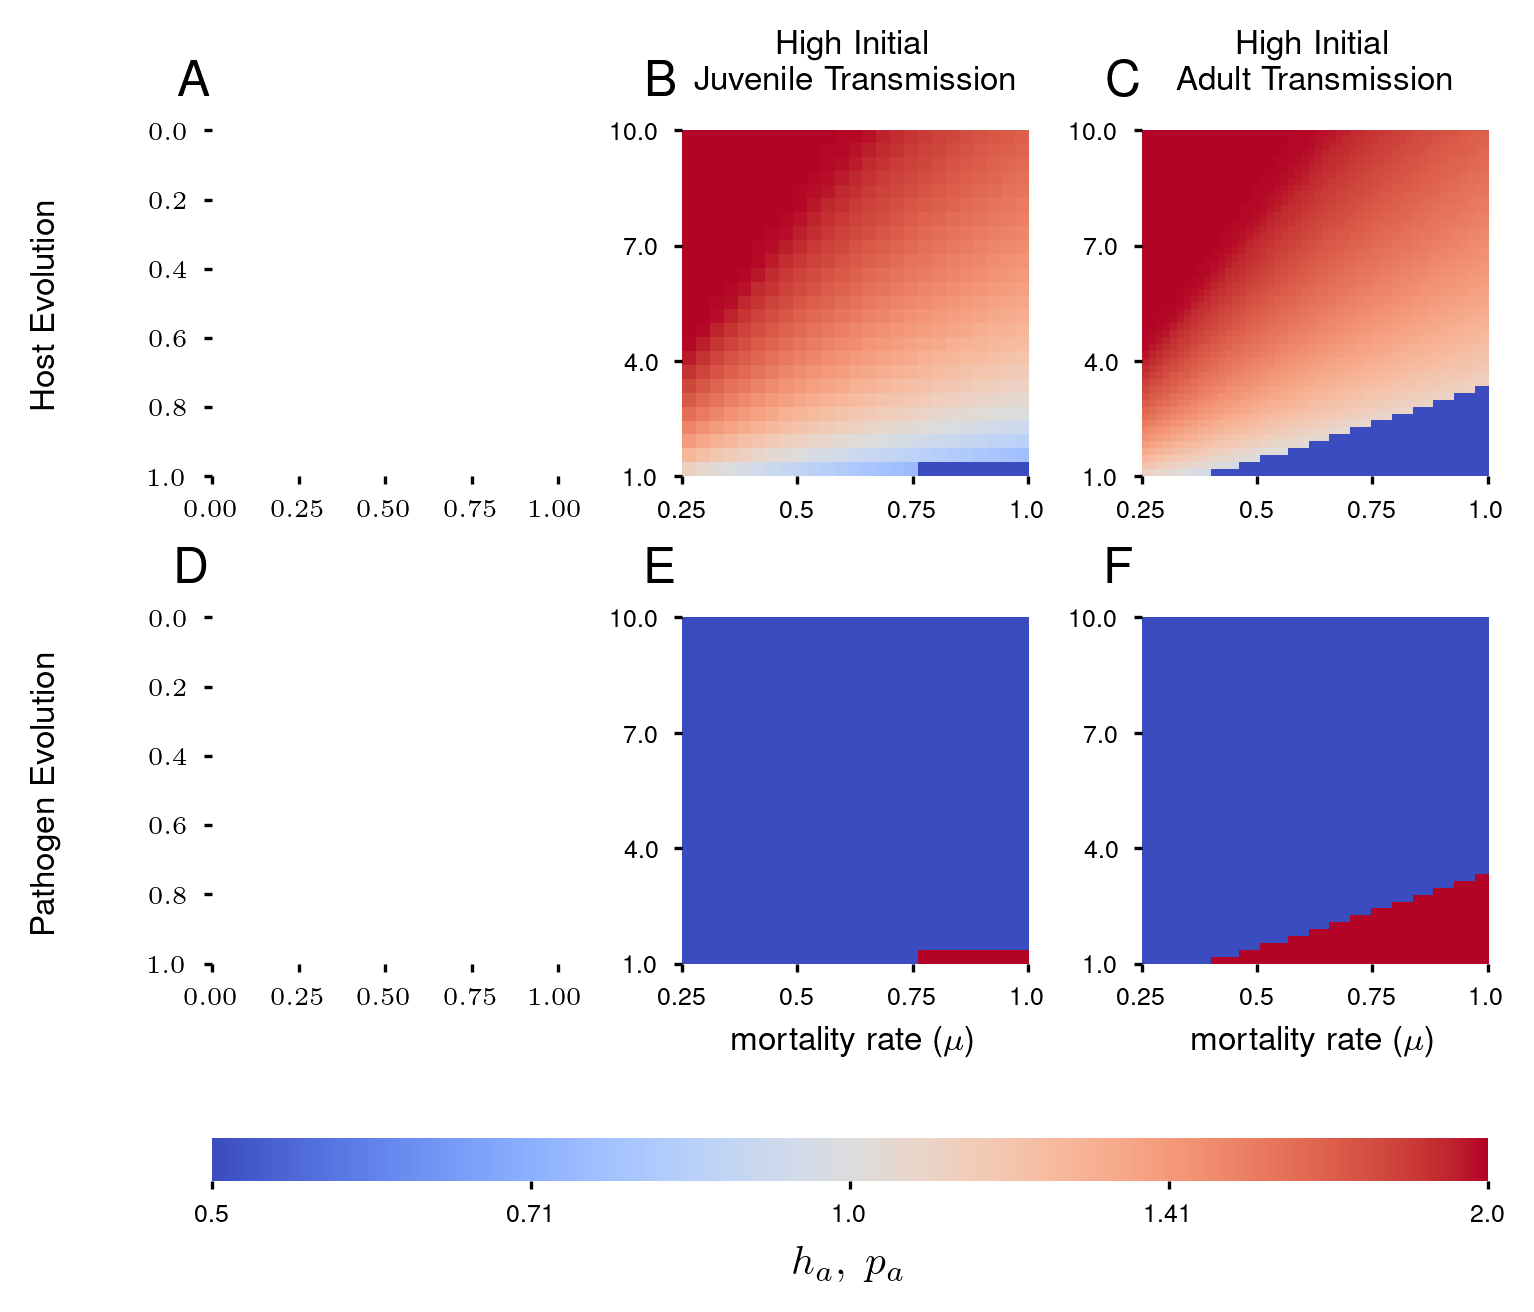

In [29]:
fig, ax = plt.subplots(figsize=(5,5), ncols=3, nrows=2, layout='compressed')

S_coevol_50, I_coevol_50, = coevol_raster_50.evol_plot()
S_coevol_60, I_coevol_60, = coevol_raster_60.evol_plot()

plot = ax[0,1].imshow(99 - S_coevol_60, cmap='coolwarm', vmin=0, vmax=99)
ax[1,1].imshow(99 - I_coevol_60, cmap='coolwarm', vmin=0, vmax=99)

ax[0,2].imshow(99 - S_coevol_50, cmap='coolwarm', vmin=0, vmax=99)
ax[1,2].imshow(99 - I_coevol_50, cmap='coolwarm', vmin=0, vmax=99)

for axis in ax.reshape(-1):
    axis.invert_yaxis()
    axis.set_frame_on(False)
    axis.tick_params('both', length=2)


coevol_raster_50.label_axes(ax[0,1], (4, 4), label_x=False, label_y=False)
coevol_raster_50.label_axes(ax[1,1], (4, 4), label_y=False, x_string=r'mortality rate ($\mu$)')
coevol_raster_60.label_axes(ax[0,2], (4, 4), label_x=False, label_y=False)
coevol_raster_60.label_axes(ax[1,2], (4, 4), label_y=False, x_string=r'mortality rate ($\mu$)')

ax[0,1].set_title('High Initial\nJuvenile Transmission', pad=10, fontsize=8)
ax[0,2].set_title('High Initial\nAdult Transmission', pad=10, fontsize=8)

ax[0,0].annotate('Host Evolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)
ax[1,0].annotate('Pathogen Evolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)

cbar = fig.colorbar(plot, ax=ax[:], location='bottom', aspect=30)
cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])
cbar.ax.tick_params(axis='both', which='both', length=2)
cbar.ax.set_xticks(np.linspace(0, 99, 5))
cbar.ax.set_xticklabels(np.round(np.logspace(-1, 1, 5, base=2), 2))
cbar.set_label(r'$h_a,\ p_a$', fontsize=10)
cbar.outline.set_visible(False)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,2].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("E", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,2].annotate("F", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)


# Figure S2: Effect of Mortality #

In [53]:
#host_path = 'data/variable_mu_50_host.p'
#path_path = 'data/default_init_50_coevol.p'
#coevol_path_50 = 'data/default_init_50_coevol.p'
#coevol_path_60 = 'data/default_init_60_coevol.p'

host_path = 'data/no_juv_trans_50_host.p'
path_path = 'data/no_juv_trans_50_path.p'
coevol_path_50 = 'data/no_juv_trans_50_coevol.p'
coevol_path_60 = 'data/no_juv_trans_60_coevol.p'

host_raster = RasterAnalysis(host_path, arg_x='m', arg_y='z')
path_raster = RasterAnalysis(path_path, arg_x='m', arg_y='z')
coevol_raster_50 = RasterAnalysis(coevol_path_50, arg_x='m', arg_y='z')
coevol_raster_60 = RasterAnalysis(coevol_path_60, arg_x='m', arg_y='z')

/tmp/ipykernel_475414/881236284.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])


Text(-0.1, 1.1, 'F')

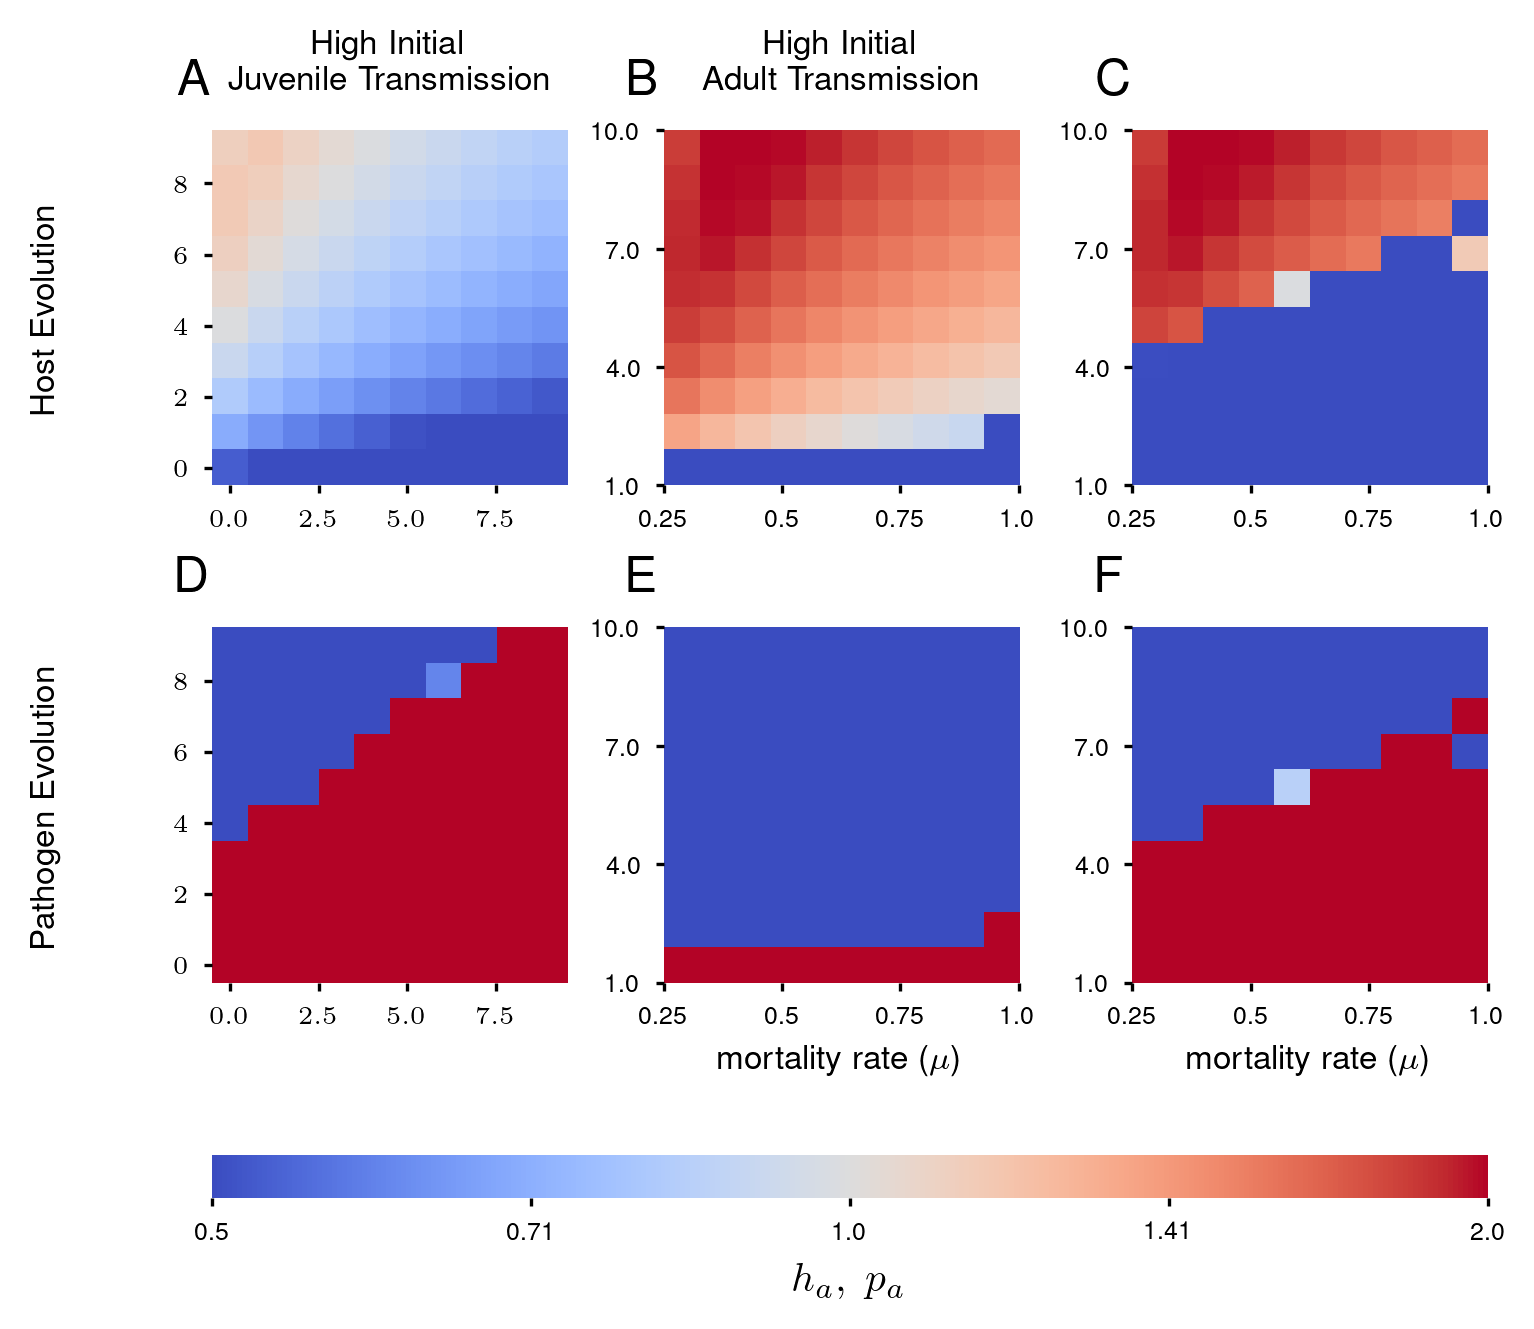

In [55]:
fig, ax = plt.subplots(figsize=(5,5), ncols=3, nrows=2, layout='compressed')

S_host, I_host = host_raster.evol_plot()
S_path, I_path = path_raster.evol_plot()
S_coevol_50, I_coevol_50, = coevol_raster_50.evol_plot()
S_coevol_60, I_coevol_60, = coevol_raster_60.evol_plot()

plot = ax[0,0].imshow(99 - S_host, cmap='coolwarm', vmin=0, vmax=99)
plot = ax[1,0].imshow(99 - I_path, cmap='coolwarm', vmin=0, vmax=99)

plot = ax[0,1].imshow(99 - S_coevol_60, cmap='coolwarm', vmin=0, vmax=99)
ax[1,1].imshow(99 - I_coevol_60, cmap='coolwarm', vmin=0, vmax=99)

ax[0,2].imshow(99 - S_coevol_50, cmap='coolwarm', vmin=0, vmax=99)
ax[1,2].imshow(99 - I_coevol_50, cmap='coolwarm', vmin=0, vmax=99)

for axis in ax.reshape(-1):
    axis.invert_yaxis()
    axis.set_frame_on(False)
    axis.tick_params('both', length=2)


coevol_raster_50.label_axes(ax[0,1], (4, 4), label_x=False, label_y=False)
coevol_raster_50.label_axes(ax[1,1], (4, 4), label_y=False, x_string=r'mortality rate ($\mu$)')
coevol_raster_60.label_axes(ax[0,2], (4, 4), label_x=False, label_y=False)
coevol_raster_60.label_axes(ax[1,2], (4, 4), label_y=False, x_string=r'mortality rate ($\mu$)')

ax[0,0].set_title('High Initial\nJuvenile Transmission', pad=10, fontsize=8)
ax[0,1].set_title('High Initial\nAdult Transmission', pad=10, fontsize=8)

ax[0,0].annotate('Host Evolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)
ax[1,0].annotate('Pathogen Evolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)

cbar = fig.colorbar(plot, ax=ax[:], location='bottom', aspect=30)
cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])
cbar.ax.tick_params(axis='both', which='both', length=2)
cbar.ax.set_xticks(np.linspace(0, 99, 5))
cbar.ax.set_xticklabels(np.round(np.logspace(-1, 1, 5, base=2), 2))
cbar.set_label(r'$h_a,\ p_a$', fontsize=10)
cbar.outline.set_visible(False)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,2].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("E", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,2].annotate("F", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)


# Figure S1: Linear Tradeoffs #

In [12]:
#Load rasters and data used for raster plots
host_path = 'default data/host.p'
path_path = 'default data/path.p'
host_raster = RasterAnalysis(host_path)
path_raster = RasterAnalysis(path_path)

params = {'m':0.5, 'mu':0.2, 'z':5, 'juv_trans':True, 'N_iter':800, 'tradeoff':'linear'}

host_model = ModelAnalysis(mode='host', **params)
path_model = ModelAnalysis(mode='coevol', **params)

In [31]:
#Load rasters and data used for raster plots
params = {'m':0.3, 'mu':0.2, 'z':5, 'juv_trans':True, 'N_iter':800, 'tradeoff':'linear'}

host_model = ModelAnalysis(mode='host', **params)
path_model = ModelAnalysis(mode='path', **params)
coevol_model = ModelAnalysis(mode='coevol', **params)

Sa_img_h, Ia_img_h, Sa_alpha_h, Ia_alpha_h = make_image(host_model.Sa, host_model.Ia)
Sa_img_p, Ia_img_p, Sa_alpha_p, Ia_alpha_p = make_image(path_model.Sa, path_model.Ia)
Sa_img_c, Ia_img_c, Sa_alpha_c, Ia_alpha_c = make_image(coevol_model.Sa, coevol_model.Ia)

In [33]:
#Load rasters and data used for raster plots
params = {'m':0.2, 'mu':0.2, 'z':3, 'juv_trans':True, 'N_iter':400, 'tradeoff':'linear', 'beta':0.002}

host_model = ModelAnalysis(mode='host', **params)
path_model = ModelAnalysis(mode='path', **params)
coevol_model = ModelAnalysis(mode='coevol', **params)

Sa_img_h, Ia_img_h, Sa_alpha_h, Ia_alpha_h = make_image(host_model.Sa, host_model.Ia)
Sa_img_p, Ia_img_p, Sa_alpha_p, Ia_alpha_p = make_image(path_model.Sa, path_model.Ia)
Sa_img_c, Ia_img_c, Sa_alpha_c, Ia_alpha_c = make_image(coevol_model.Sa, coevol_model.Ia)

Text(-0.1, 1.1, 'C')

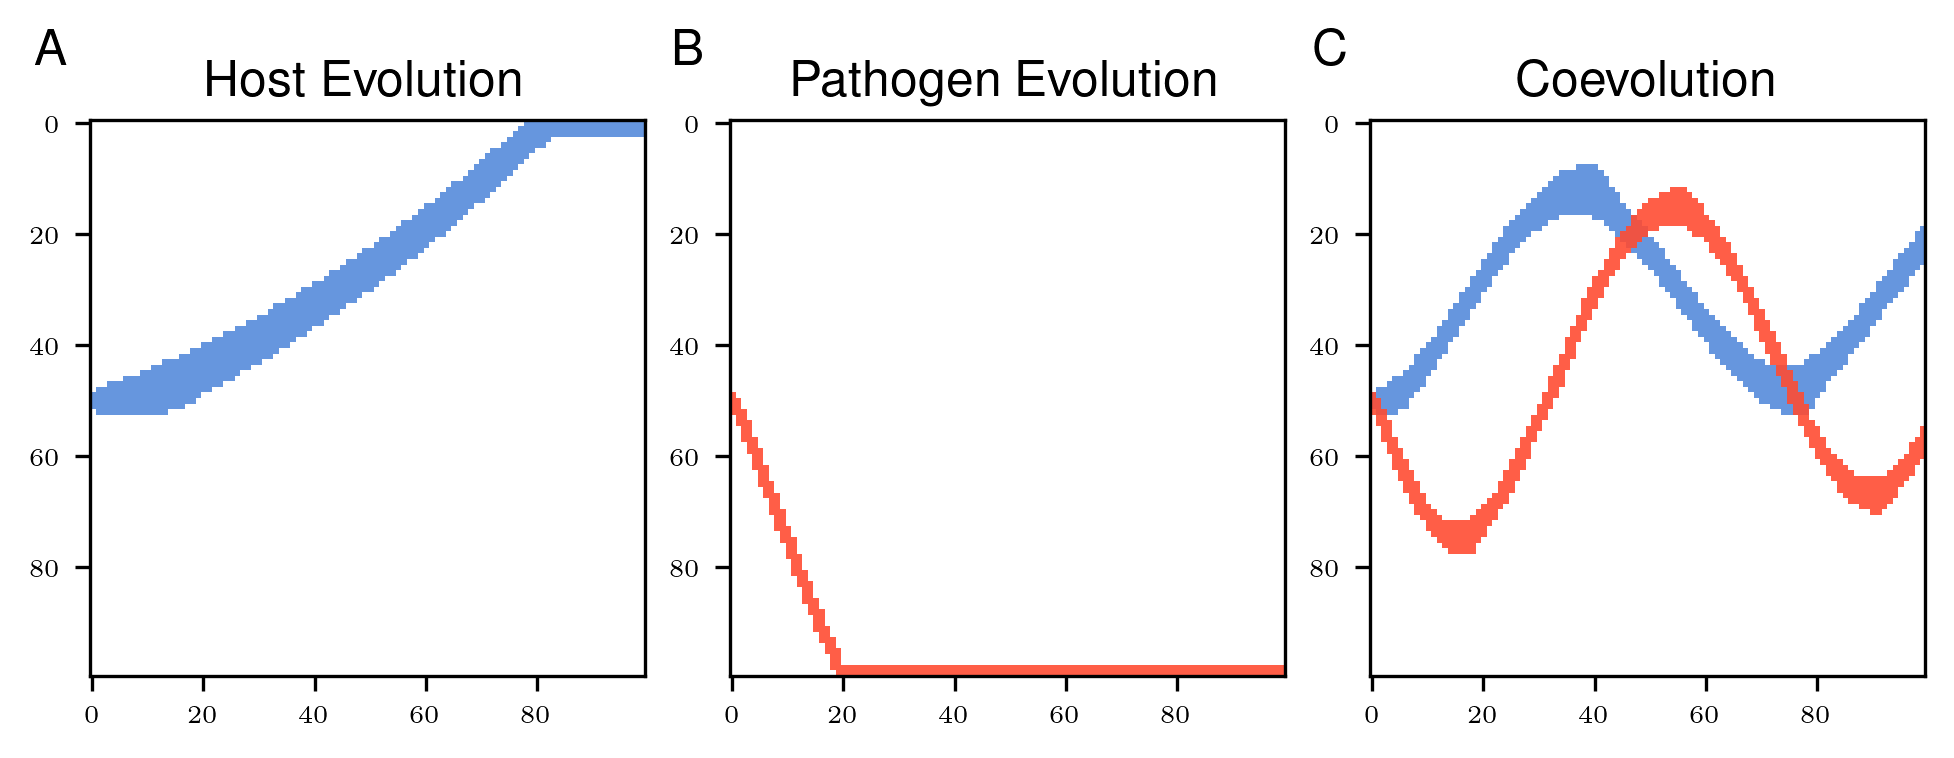

In [34]:
fig, ax = plt.subplots(ncols=3, nrows=1, layout='compressed')

ax[0].imshow(Sa_img_h, alpha=Sa_alpha_h, cmap=s_cmap)
ax[1].imshow(Ia_img_p, alpha=Ia_alpha_p, cmap=i_cmap)
ax[2].imshow(Sa_img_c, alpha=Sa_alpha_c, cmap=s_cmap)
ax[2].imshow(Ia_img_c, alpha=Ia_alpha_c, cmap=i_cmap)

ax[0].set_title('Host Evolution')
ax[1].set_title('Pathogen Evolution')
ax[2].set_title('Coevolution')

def label_x_axis(ax, n_x_ticks = 3):
    x_lim = ax.get_xlim()
    x_ticks = np.linspace(x_lim[0], x_lim[1], n_x_ticks)
    x_tick_labels = np.linspace(0, host_model.N_iter, n_x_ticks)

    ax.set_xticks(x_ticks, x_tick_labels.astype(int))


ax[0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[2].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)

# Figure S2: Non-Equal Rates of Evolution #

In [5]:
coevol_path_50 = 'data/fast_pathogen_evolution_init_50_coevol.p'
coevol_path_60 = 'data/fast_pathogen_evolution_init_60_coevol.p'

coevol_raster_50 = RasterAnalysis(coevol_path_50, arg_x='m', arg_y='z')
coevol_raster_60 = RasterAnalysis(coevol_path_60, arg_x='m', arg_y='z')

/tmp/ipykernel_469821/2904078046.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])


Text(-0.1, 1.1, 'D')

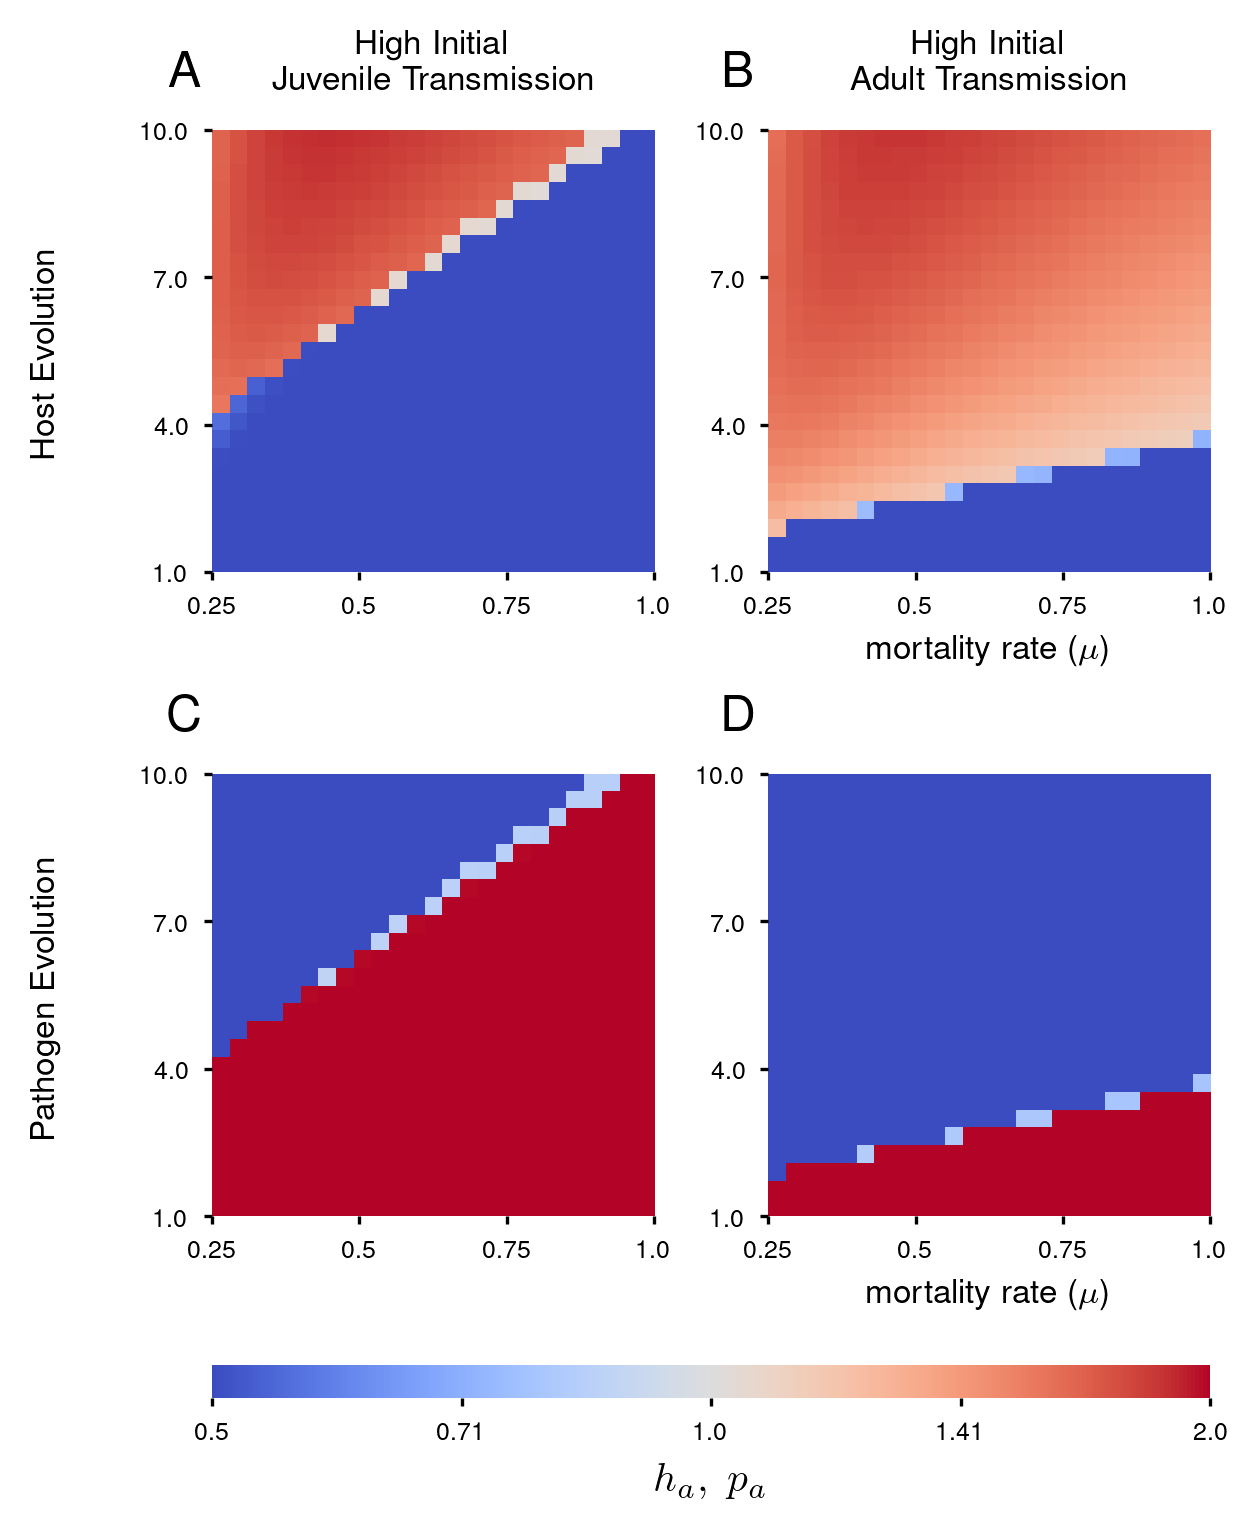

In [ ]:
fig, ax = plt.subplots(figsize=(5,5), ncols=2, nrows=2, layout='compressed')

S_coevol_50, I_coevol_50, = coevol_raster_50.evol_plot()
S_coevol_60, I_coevol_60, = coevol_raster_60.evol_plot()

plot = ax[0,0].imshow(99 - S_coevol_50, cmap='coolwarm', vmin=0, vmax=99)
ax[1,0].imshow(99 - I_coevol_50, cmap='coolwarm', vmin=0, vmax=99)

ax[0,1].imshow(99 - S_coevol_60, cmap='coolwarm', vmin=0, vmax=99)
ax[1,1].imshow(99 - I_coevol_60, cmap='coolwarm', vmin=0, vmax=99)

for axis in ax.reshape(-1):
    axis.invert_yaxis()
    axis.set_frame_on(False)
    axis.tick_params('both', length=2)


coevol_raster_50.label_axes(ax[0,0], (4, 4), label_x=False, label_y=False)
coevol_raster_50.label_axes(ax[0,1], (4, 4), label_y=False, x_string=r'mortality rate ($\mu$)')
coevol_raster_60.label_axes(ax[1,0], (4, 4), label_x=False, label_y=False)
coevol_raster_60.label_axes(ax[1,1], (4, 4), label_y=False, x_string=r'mortality rate ($\mu$)')

ax[0,0].set_title('High Initial\nJuvenile Transmission', pad=10, fontsize=8)
ax[0,1].set_title('High Initial\nAdult Transmission', pad=10, fontsize=8)

ax[0,0].annotate('Host Evolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)
ax[1,0].annotate('Pathogen Evolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)

cbar = fig.colorbar(plot, ax=ax[:], location='bottom', aspect=30)
cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])
cbar.ax.tick_params(axis='both', which='both', length=2)
cbar.ax.set_xticks(np.linspace(0, 99, 5))
cbar.ax.set_xticklabels(np.round(np.logspace(-1, 1, 5, base=2), 2))
cbar.set_label(r'$h_a,\ p_a$', fontsize=10)
cbar.outline.set_visible(False)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)


In [20]:
#Load rasters and data used for raster plots
#PARAMETERS RESULT IN FLIP
params = {'m':0.5, 'mu':0.2, 'z':5, 'juv_trans':True, 'N_iter':200, 'fast_path':True}
params_2 = {'m':0.5, 'mu':0.2, 'z':5, 'juv_trans':True, 'N_iter':200, 'fast_path':False}

path_model = ModelAnalysis(mode='coevol', **params)
reg_model = ModelAnalysis(mode='coevol', **params_2)

In [17]:
#Load rasters and data used for raster plots
params = {'m':0.8, 'mu':0.2, 'z':2, 'juv_trans':True, 'N_iter':200, 'fast_path':True}
params_2 = {'m':0.8, 'mu':0.2, 'z':2, 'juv_trans':True, 'N_iter':200, 'fast_path':False}

path_model = ModelAnalysis(mode='coevol', **params)
reg_model = ModelAnalysis(mode='coevol', **params_2)

In [18]:
Sa_img_fp, Ia_img_fp, Sa_alpha_fp, Ia_alpha_fp = make_image(path_model.Sa, path_model.Ia)
Sa_img_r, Ia_img_r, Sa_alpha_r, Ia_alpha_r = make_image(reg_model.Sa, reg_model.Ia)

Text(-0.1, 1.1, 'B')

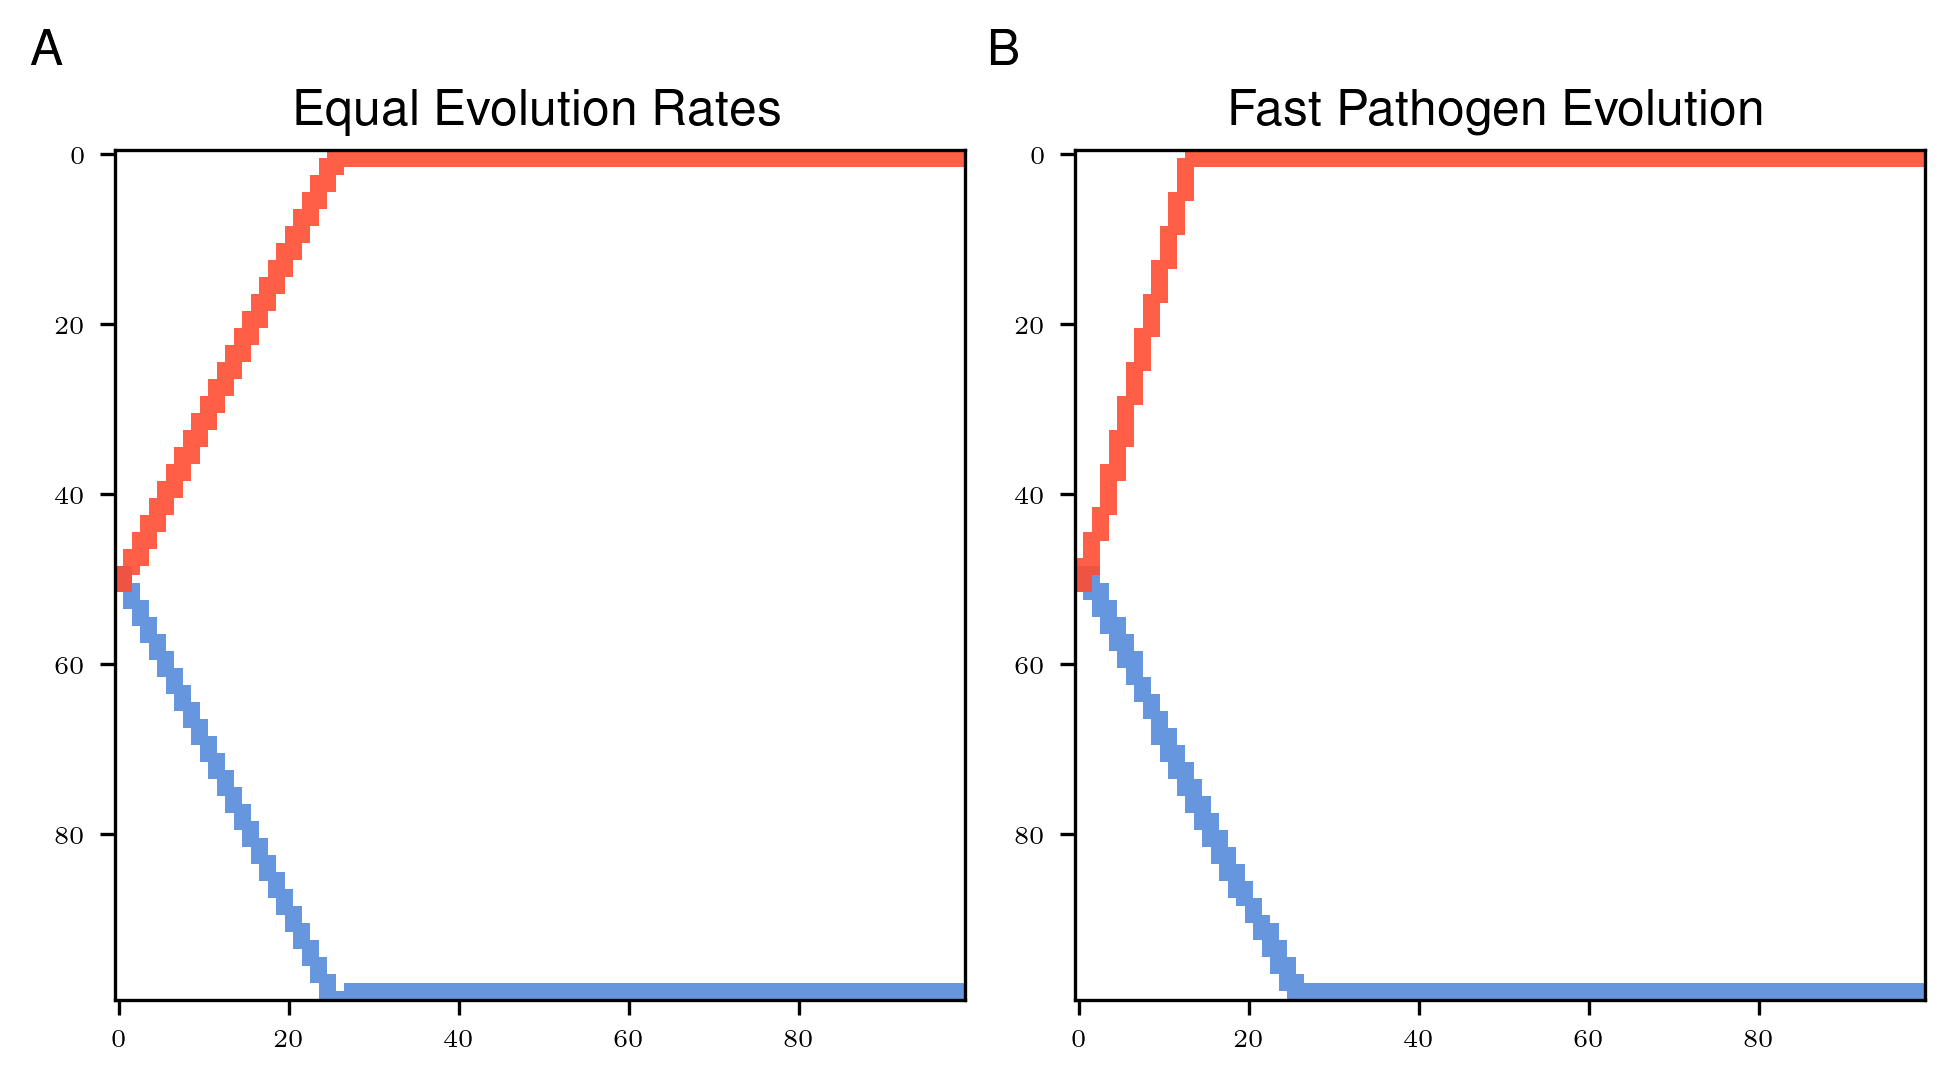

In [19]:
fig, ax = plt.subplots(ncols=2, nrows=1, layout='compressed')

ax[0].imshow(Sa_img_r, alpha=Sa_alpha_r, cmap=s_cmap)
ax[0].imshow(Ia_img_r, alpha=Ia_alpha_r, cmap=i_cmap)
ax[1].imshow(Sa_img_fp, alpha=Sa_alpha_fp, cmap=s_cmap)
ax[1].imshow(Ia_img_fp, alpha=Ia_alpha_fp, cmap=i_cmap)

ax[0].set_title('Equal Evolution Rates')
ax[1].set_title('Fast Pathogen Evolution')

def label_x_axis(ax, n_x_ticks = 3):
    x_lim = ax.get_xlim()
    x_ticks = np.linspace(x_lim[0], x_lim[1], n_x_ticks)
    x_tick_labels = np.linspace(0, host_model.N_iter, n_x_ticks)

    ax.set_xticks(x_ticks, x_tick_labels.astype(int))


ax[0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
